# Part 1 — Steps 8, 9 & 10: Evaluation, Result Analysis & Model Enhancement
**Steps covered:**
- **Evaluation** — R², RMSE, MAE per target + graphical metrics
- **Result Analysis** — Predicted vs Actual, residuals, per-output breakdown
- **Model Enhancement** — Hyperparameter tuning with GridSearchCV (best model)

Run after `agriculture_training.ipynb`.

In [1]:
# ── Cell 1 : Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle

from sklearn.metrics        import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble       import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Cell 2 : Load splits and trained models ───────────────────────────────────
with open('splits/split_data.pkl', 'rb') as f:
    s = pickle.load(f)
with open('models/rf_model.pkl',   'rb') as f: rf  = pickle.load(f)
with open('models/svr_model.pkl',  'rb') as f: svr = pickle.load(f)
with open('models/mlp_model.pkl',  'rb') as f: mlp = pickle.load(f)

X_train = s['X_train'];  y_train = s['y_train']
X_val   = s['X_val'];    y_val   = s['y_val']
X_test  = s['X_test'];   y_test  = s['y_test']
TARGET_COLS = s['target_cols']

MODELS = {'RandomForest': rf, 'SVR': svr, 'MLP': mlp}
print('Models and splits loaded.')

Models and splits loaded.


---
## Part A — Evaluation Metrics

In [3]:
# ── Cell 3 : Full metrics table — per-target breakdown ────────────────────────

rows = []
for name, model in MODELS.items():
    y_pred = model.predict(X_test)
    for i, target in enumerate(TARGET_COLS):
        yt = y_test[:, i]
        yp = y_pred[:, i]
        rows.append({
            'Model'   : name,
            'Target'  : target.replace('_L_ha','').replace('_kg_ha',''),
            'R²'      : round(r2_score(yt, yp), 4),
            'RMSE'    : round(np.sqrt(mean_squared_error(yt, yp)), 3),
            'MAE'     : round(mean_absolute_error(yt, yp), 3),
        })

df_eval = pd.DataFrame(rows)
print(df_eval.to_string(index=False))

       Model           Target     R²   RMSE    MAE
RandomForest water_allocation 0.5503 69.121 31.968
RandomForest     fertilizer_N 0.7727 16.385 12.253
RandomForest     fertilizer_P 0.5756 10.745  8.274
         SVR water_allocation 0.3174 85.161 37.300
         SVR     fertilizer_N 0.9396  8.443  5.436
         SVR     fertilizer_P 0.9082  4.998  2.986
         MLP water_allocation 0.4586 75.840 31.681
         MLP     fertilizer_N 0.9285  9.191  6.097
         MLP     fertilizer_P 0.8558  6.263  4.337


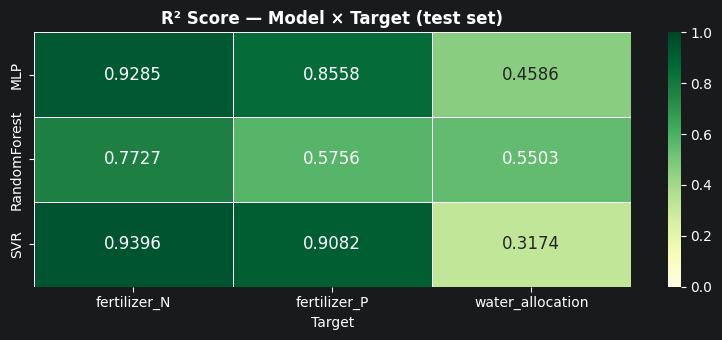

In [4]:
# ── Cell 4 : R² heatmap — Models × Targets ────────────────────────────────────

r2_pivot = df_eval.pivot(index='Model', columns='Target', values='R²')

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(
    r2_pivot, annot=True, fmt='.4f',
    cmap='YlGn', vmin=0, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 12}
)
ax.set_title('R² Score — Model × Target (test set)', fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('eval_r2_heatmap.png', dpi=120)
plt.show()

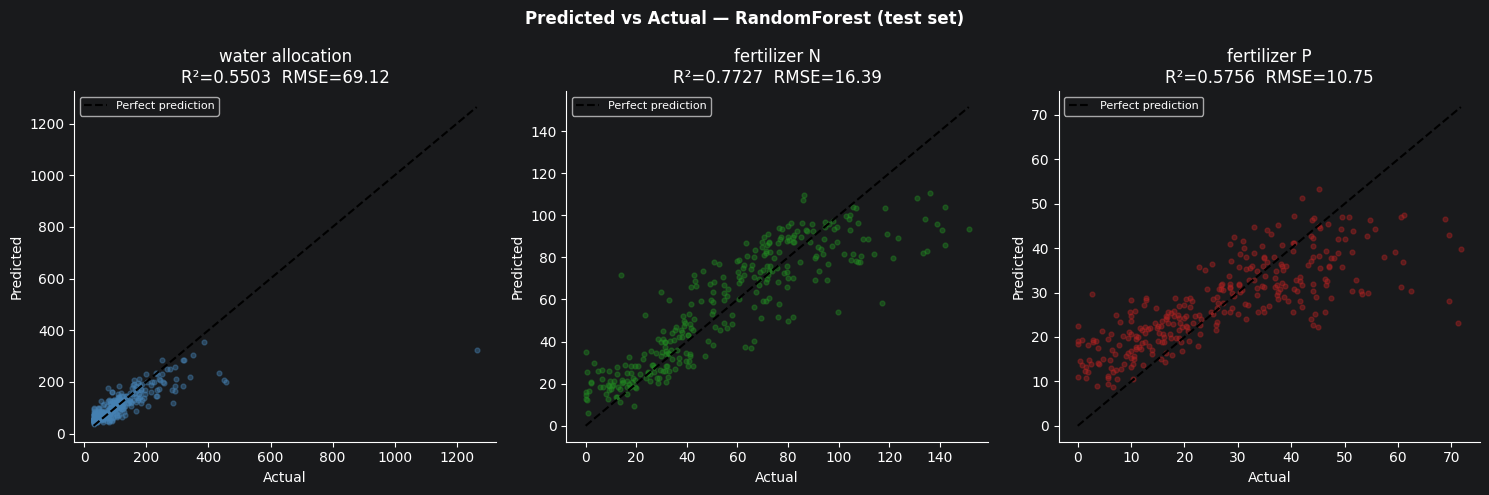

In [5]:
# ── Cell 5 : Predicted vs Actual — best model per target ─────────────────────

y_pred_rf = rf.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Predicted vs Actual — RandomForest (test set)', fontweight='bold')

colors = ['steelblue', 'forestgreen', 'firebrick']
for ax, i, col, color in zip(axes, range(3), TARGET_COLS, colors):
    yt, yp = y_test[:, i], y_pred_rf[:, i]
    ax.scatter(yt, yp, alpha=0.4, s=12, color=color)
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect prediction')
    r2 = r2_score(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    short = col.replace('_L_ha','').replace('_kg_ha','').replace('_',' ')
    ax.set_title(f'{short}\nR²={r2:.4f}  RMSE={rmse:.2f}')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('eval_pred_vs_actual.png', dpi=120)
plt.show()

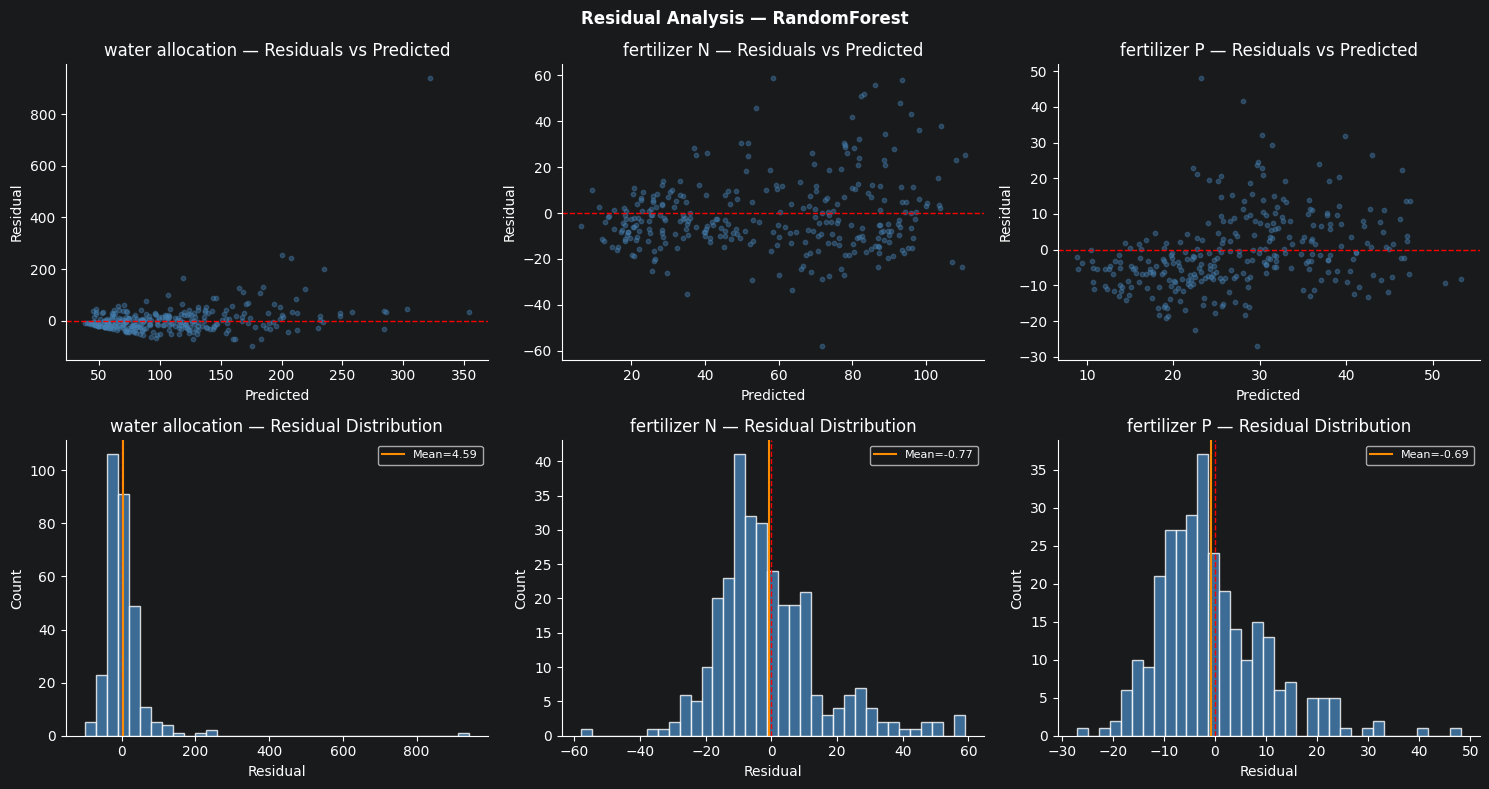

In [6]:
# ── Cell 6 : Residual analysis ───────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Residual Analysis — RandomForest', fontweight='bold')

for col_idx, col in enumerate(TARGET_COLS):
    yt    = y_test[:, col_idx]
    yp    = y_pred_rf[:, col_idx]
    resid = yt - yp
    short = col.replace('_L_ha','').replace('_kg_ha','').replace('_',' ')

    # Top row: residuals vs predicted
    ax = axes[0, col_idx]
    ax.scatter(yp, resid, alpha=0.4, s=10, color='steelblue')
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual')
    ax.set_title(f'{short} — Residuals vs Predicted')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Bottom row: residual distribution
    ax = axes[1, col_idx]
    ax.hist(resid, bins=35, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.axvline(resid.mean(), color='darkorange', linestyle='-', linewidth=1.5,
               label=f'Mean={resid.mean():.2f}')
    ax.set_xlabel('Residual')
    ax.set_ylabel('Count')
    ax.set_title(f'{short} — Residual Distribution')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('eval_residuals.png', dpi=120)
plt.show()

---
## Part B — Result Analysis

In [7]:
# ── Cell 7 : Detailed result analysis ────────────────────────────────────────

print('=' * 60)
print('  RESULT ANALYSIS — RandomForest Multi-output Regression')
print('=' * 60)

for i, col in enumerate(TARGET_COLS):
    yt    = y_test[:, i]
    yp    = y_pred_rf[:, i]
    resid = yt - yp
    r2    = r2_score(yt, yp)
    rmse  = np.sqrt(mean_squared_error(yt, yp))
    mae   = mean_absolute_error(yt, yp)
    bias  = resid.mean()
    short = col.replace('_',' ')

    print(f'\n  Target: {short}')
    print(f'    R²       : {r2:.4f}', end='  ')
    if r2 >= 0.90:
        print('[Excellent — strong linear fit]')
    elif r2 >= 0.75:
        print('[Good — model explains most variance]')
    elif r2 >= 0.60:
        print('[Moderate — some unexplained variance]')
    else:
        print('[Weak — consider feature review or different model]')
    print(f'    RMSE     : {rmse:.3f}')
    print(f'    MAE      : {mae:.3f}')
    print(f'    Bias     : {bias:.3f}  (mean residual — close to 0 is good)')
    print(f'    Actual range   : [{yt.min():.1f}, {yt.max():.1f}]')
    print(f'    Predicted range: [{yp.min():.1f}, {yp.max():.1f}]')

  RESULT ANALYSIS — RandomForest Multi-output Regression

  Target: water allocation L ha
    R²       : 0.5503  [Weak — consider feature review or different model]
    RMSE     : 69.121
    MAE      : 31.968
    Bias     : 4.587  (mean residual — close to 0 is good)
    Actual range   : [30.0, 1263.8]
    Predicted range: [38.5, 353.8]

  Target: fertilizer N kg ha
    R²       : 0.7727  [Good — model explains most variance]
    RMSE     : 16.385
    MAE      : 12.253
    Bias     : -0.769  (mean residual — close to 0 is good)
    Actual range   : [0.0, 151.4]
    Predicted range: [6.2, 110.5]

  Target: fertilizer P kg ha
    R²       : 0.5756  [Weak — consider feature review or different model]
    RMSE     : 10.745
    MAE      : 8.274
    Bias     : -0.690  (mean residual — close to 0 is good)
    Actual range   : [0.0, 71.8]
    Predicted range: [8.8, 53.3]


---
## Part C — Model Enhancement (Hyperparameter Tuning)

In [8]:
# ── Cell 8 : GridSearchCV on RandomForest ────────────────────────────────────
#
# We tune the 4 most impactful hyperparameters:
#   - n_estimators  : number of trees
#   - max_depth     : maximum tree depth (controls overfitting)
#   - min_samples_split : minimum samples to split an internal node
#   - max_features  : fraction of features considered at each split
#
# GridSearchCV uses 5-fold cross-validation internally.
# ─────────────────────────────────────────────────────────────────────────────

param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features'     : ['sqrt', 0.5, 0.8],
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=5,
    scoring='r2',
    refit=True,         # refit best model on full training set
    n_jobs=-1,
    verbose=1
)

print('Running GridSearchCV... (this may take a few minutes)')
import time
t0 = time.time()
grid_search.fit(X_train, y_train)
print(f'Done in {time.time()-t0:.0f}s')

print('\nBest parameters found:')
for k, v in grid_search.best_params_.items():
    print(f'  {k:<22}: {v}')
print(f'\nBest CV R²: {grid_search.best_score_:.4f}')

Running GridSearchCV... (this may take a few minutes)
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Done in 50s

Best parameters found:
  max_depth             : None
  max_features          : 0.5
  min_samples_split     : 2
  n_estimators          : 300

Best CV R²: 0.6700


In [9]:
# ── Cell 9 : Evaluate tuned model vs baseline ─────────────────────────────────

rf_tuned = grid_search.best_estimator_
y_pred_tuned = rf_tuned.predict(X_test)

r2_baseline = r2_score(y_test, y_pred_rf,    multioutput='uniform_average')
r2_tuned    = r2_score(y_test, y_pred_tuned, multioutput='uniform_average')
rmse_base   = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rmse_tuned  = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print('\n=== Before vs After Hyperparameter Tuning ===')
print(f'  Baseline RF  — Test R²={r2_baseline:.4f}  RMSE={rmse_base:.3f}')
print(f'  Tuned RF     — Test R²={r2_tuned:.4f}  RMSE={rmse_tuned:.3f}')
improvement = (r2_tuned - r2_baseline) / abs(r2_baseline) * 100
print(f'  Improvement  : {improvement:+.2f}% in R²')


=== Before vs After Hyperparameter Tuning ===
  Baseline RF  — Test R²=0.6329  RMSE=41.479
  Tuned RF     — Test R²=0.7022  RMSE=33.824
  Improvement  : +10.96% in R²


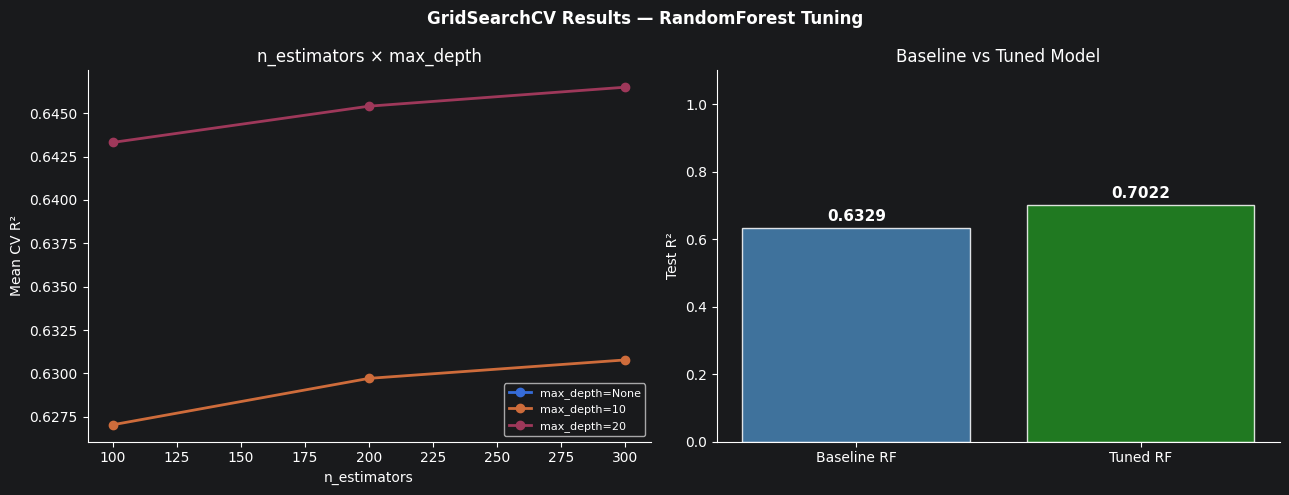

In [10]:
# ── Cell 10 : Visualise GridSearch results ────────────────────────────────────

cv_results_df = pd.DataFrame(grid_search.cv_results_)

# Plot mean test score vs n_estimators for each max_depth
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('GridSearchCV Results — RandomForest Tuning', fontweight='bold')

# Plot 1: effect of n_estimators × max_depth
ax = axes[0]
for depth in [None, 10, 20]:
    mask = cv_results_df['param_max_depth'] == depth
    grouped = cv_results_df[mask].groupby('param_n_estimators')['mean_test_score'].mean()
    label = f'max_depth={depth}'
    ax.plot(grouped.index, grouped.values, 'o-', linewidth=2, label=label)
ax.set_xlabel('n_estimators')
ax.set_ylabel('Mean CV R²')
ax.set_title('n_estimators × max_depth')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Plot 2: Before vs after bar chart
ax = axes[1]
bars = ax.bar(['Baseline RF', 'Tuned RF'],
              [r2_baseline, r2_tuned],
              color=['steelblue', 'forestgreen'], alpha=0.85, edgecolor='white')
ax.set_ylabel('Test R²')
ax.set_title('Baseline vs Tuned Model')
ax.set_ylim(0, 1.1)
for bar, val in zip(bars, [r2_baseline, r2_tuned]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('eval_tuning_results.png', dpi=120)
plt.show()

In [11]:
# ── Cell 11 : Final model — per-target evaluation after tuning ────────────────

print('=== Final Tuned Model — Per-Target Test Performance ===')
for i, col in enumerate(TARGET_COLS):
    yt = y_test[:, i]
    yp = y_pred_tuned[:, i]
    short = col.replace('_L_ha','').replace('_kg_ha','').replace('_',' ')
    print(f'  {short:<30}  R²={r2_score(yt,yp):.4f}  '
          f'RMSE={np.sqrt(mean_squared_error(yt,yp)):.3f}  '
          f'MAE={mean_absolute_error(yt,yp):.3f}')

=== Final Tuned Model — Per-Target Test Performance ===
  water allocation                R²=0.7105  RMSE=55.461  MAE=31.830
  fertilizer N                    R²=0.7887  RMSE=15.798  MAE=11.639
  fertilizer P                    R²=0.6074  RMSE=10.334  MAE=7.984


In [12]:
# ── Cell 12 : Save final tuned model ──────────────────────────────────────────
with open('models/rf_tuned_model.pkl', 'wb') as f:
    pickle.dump(rf_tuned, f)

# Export final predictions to CSV
df_preds = pd.DataFrame(y_test, columns=[f'actual_{c}' for c in TARGET_COLS])
for i, c in enumerate(TARGET_COLS):
    df_preds[f'predicted_{c}'] = y_pred_tuned[:, i]
df_preds.to_csv('datasets/final_predictions.csv', index=False)

print('Saved: models/rf_tuned_model.pkl')
print('Saved: datasets/final_predictions.csv')
print()
print('========================================')
print('  PROJECT PART 1 — COMPLETE')
print('========================================')
print(f'  Final Test R²  : {r2_tuned:.4f}')
print(f'  Final RMSE     : {rmse_tuned:.3f}')
print(f'  Best params    : {grid_search.best_params_}')

Saved: models/rf_tuned_model.pkl
Saved: datasets/final_predictions.csv

  PROJECT PART 1 — COMPLETE
  Final Test R²  : 0.7022
  Final RMSE     : 33.824
  Best params    : {'max_depth': None, 'max_features': 0.5, 'min_samples_split': 2, 'n_estimators': 300}
